# Copyright (c) Meta Platforms, Inc. and affiliates.


## Image segmentation with EfficientSAM3

This notebook demonstrates how to use EfficientSAM3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts


# <a target="_blank" href="https://colab.research.google.com/github/SimonZeng7108/efficientsam3/blob/main/efficientsam3_examples/efficientsam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>


In [1]:
using_colab = False


In [2]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/SimonZeng7108/efficientsam3.git'


In [3]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

/home/simon7108528_msi_linux/miniconda3/envs/efficientsam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/mnt/e/side_projects/efficientsam3/sam3/sam3/backbones/repvit.py:276: UserWarning: Overwriting repvit_m0_9 in registry with sam3.backbones.repvit.repvit_m0_9. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/mnt/e/side_projects/efficientsam3/sam3/sam3/backbones/repvit.py:312: UserWarning: Overwriting repvit_m1_0 in registry with sam3.backbones.repvit.repvit_m1_0. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/mnt/e/side_projects/efficientsam3/sam3/sam3/backbones/repvit.py:349: UserWarning: Overwriting re

In [4]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()


# Build Model
Note: When using a merged checkpoint (containing both image and text student encoders), you must specify the `backbone_type`, `model_name`, and `text_encoder_type` to ensure the correct architecture is built.


In [5]:
import torch
from sam3.model.efficient_sam3 import EfficientSam3Tracker
from sam3.model_builder import build_efficientsam3_image_model

# 1. Build the Student Backbone (EfficientViT + MobileCLIP)
# We use the Stage 1 builder to get the correct lightweight backbone structure.
# We MUST enable instance interactivity to get the SAM2-style neck features required for tracking.
print("Building Student Backbone (EfficientViT-B0 + MobileCLIP-S0)...")
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
dummy_student = build_efficientsam3_image_model(
    bpe_path=bpe_path,
    checkpoint_path=None, # We will load weights later
    load_from_HF=False,
    backbone_type="efficientvit",
    model_name="b0",
    text_encoder_type="MobileCLIP-S0",
    enable_inst_interactivity=True, # Required for tracking (adds sam2_convs)
)
student_backbone = dummy_student.backbone

# 2. Initialize EfficientSam3Tracker with Student Backbone
print("Initializing EfficientSam3Tracker...")
model = EfficientSam3Tracker(
    backbone=student_backbone,
    hybrid_memory_dim=256,
    num_global_latents=64,
    num_spatial_latents=192,
    window_size=8
)

# 3. Load the Final Merged Checkpoint
# This checkpoint contains:
# - Student Backbone (Vision + Text)
# - Trained Efficient Memory Module
# - SAM Heads
checkpoint_path = "/home/simon7108528_msi_linux/e-drive/side_projects/efficientsam3/output/efficient_sam3_final.pt"
if os.path.exists(checkpoint_path):
    print(f"Loading Final Merged checkpoint from {checkpoint_path}...")
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    
    # Load state dict
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Checkpoint loaded.")
    if missing:
        print(f"Missing keys: {len(missing)}")
        # Check if sam2_convs are missing (likely if Stage 1 didn't use enable_inst_interactivity)
        sam2_missing = [k for k in missing if "sam2_convs" in k]
        if sam2_missing:
            print(f"Found {len(sam2_missing)} missing sam2_convs keys. Copying from convs...")
            # Copy weights from convs to sam2_convs
            neck = model.backbone.vision_backbone
            if neck.sam2_convs is not None:
                neck.sam2_convs.load_state_dict(neck.convs.state_dict())
                print("Weights copied from convs to sam2_convs.")
            
    if unexpected:
        print(f"Unexpected keys: {len(unexpected)}")
else:
    print(f"Checkpoint not found at {checkpoint_path}")

model.eval()
model.to("cuda")
print("Model ready on CUDA.")


Building Student Backbone (EfficientViT-B0 + MobileCLIP-S0)...
Initializing EfficientSam3Tracker...
Loading Final Merged checkpoint from /home/simon7108528_msi_linux/e-drive/side_projects/efficientsam3/output/efficient_sam3_final.pt...
Initializing EfficientSam3Tracker...
Loading Final Merged checkpoint from /home/simon7108528_msi_linux/e-drive/side_projects/efficientsam3/output/efficient_sam3_final.pt...
Checkpoint loaded.
Unexpected keys: 420
Model ready on CUDA.
Checkpoint loaded.
Unexpected keys: 420
Model ready on CUDA.


In [6]:
import shutil

# Prepare a temporary "video" directory with the single image
# The tracker API expects a video (sequence of frames) or a directory of images.
image_path = f"{sam3_root}/assets/images/test_image.jpg"
video_dir = "temp_video_input"
if os.path.exists(video_dir):
    shutil.rmtree(video_dir)
os.makedirs(video_dir)

# Copy image to video dir as frame 00000.jpg
shutil.copy(image_path, os.path.join(video_dir, "00000.jpg"))

# Initialize Tracker State
inference_state = model.init_state(video_path=video_dir)
print("Tracker state initialized.")

# Helper to visualize results
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))


frame loading (JPEG):   0%|          | 0/1 [00:00<?, ?it/s]

frame loading (JPEG): 100%|██████████| 1/1 [00:00<00:00, 26.93it/s]

Tracker state initialized.


# Text prompt


In [7]:
# Text prompt is not directly supported in the low-level Tracker API used here.
# The EfficientSam3Tracker focuses on memory-based tracking.
# To use text prompts, one would typically use the full Sam3VideoInference pipeline which integrates the detector.
print("Skipping Text Prompt for Tracker API usage.")


Skipping Text Prompt for Tracker API usage.


### Visual prompt: a single bounding box


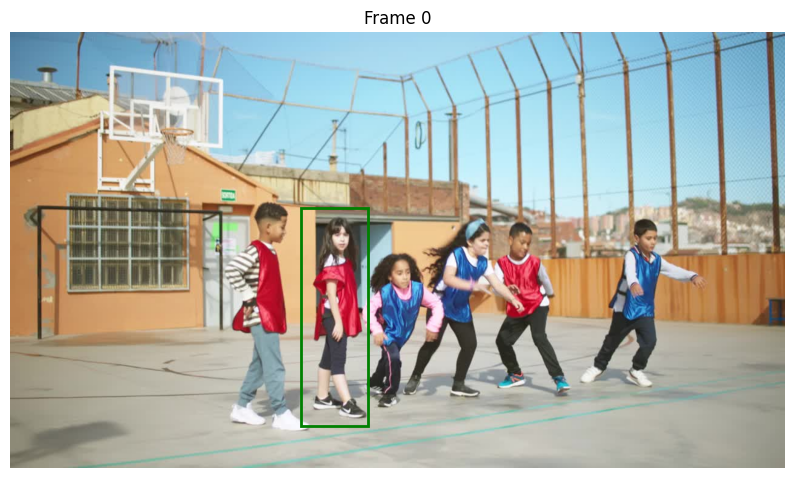

In [8]:
# Visual prompt: a single bounding box
# Box format: [x1, y1, x2, y2]
box_input = np.array([480.0, 290.0, 480.0+110.0, 290.0+360.0], dtype=np.float32)

frame_idx = 0
obj_id = 1

# Add box prompt to the tracker
# Returns: frame_idx, obj_ids, low_res_masks, video_res_masks
_, out_obj_ids, _, out_masks = model.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=frame_idx,
    obj_id=obj_id,
    box=box_input,
)

# Visualize
plt.figure(figsize=(10, 10))
plt.title(f"Frame {frame_idx}")
img = Image.open(os.path.join(video_dir, "00000.jpg"))
plt.imshow(img)
show_box(box_input, plt.gca())
show_mask((out_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])
plt.axis('off')
plt.show()


### Visual prompt: multi-box prompting (with positive and negative boxes)


frame loading (JPEG): 100%|██████████| 1/1 [00:00<00:00, 38.86it/s]



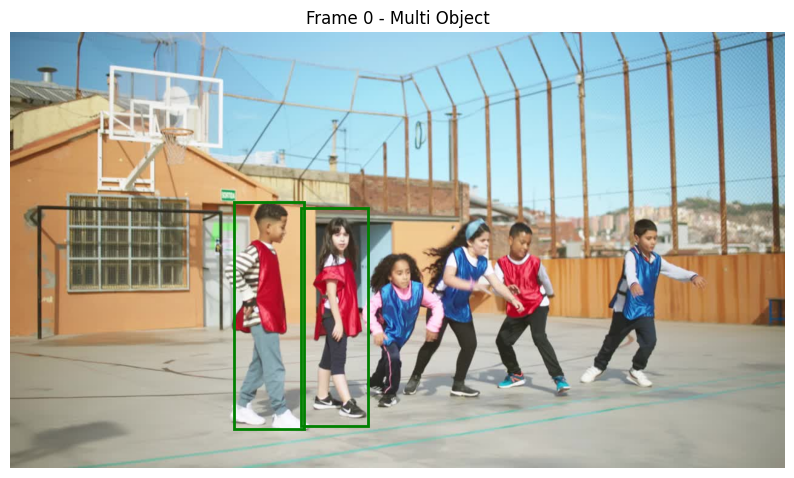

In [9]:
# Visual prompt: multi-box prompting
# We can add multiple objects by calling add_new_points_or_box with different obj_ids

# Reset state for this example
inference_state = model.init_state(video_path=video_dir)

box_input_1 = np.array([480.0, 290.0, 480.0+110.0, 290.0+360.0], dtype=np.float32) # Object 1
box_input_2 = np.array([370.0, 280.0, 370.0+115.0, 280.0+375.0], dtype=np.float32) # Object 2

# Add Object 1
_, out_obj_ids_1, _, out_masks_1 = model.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    box=box_input_1,
)

# Add Object 2
_, out_obj_ids_2, _, out_masks_2 = model.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=2,
    box=box_input_2,
)

# Visualize
plt.figure(figsize=(10, 10))
plt.title(f"Frame 0 - Multi Object")
img = Image.open(os.path.join(video_dir, "00000.jpg"))
plt.imshow(img)

# Show Object 1
show_box(box_input_1, plt.gca())
show_mask((out_masks_1[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=1)

# Show Object 2
show_box(box_input_2, plt.gca())
show_mask((out_masks_2[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=2)

plt.axis('off')
plt.show()
